# Cell 1: Analytical Kirsch Solution vs. Dataset Generation for Machine Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Geometric & Physics Parameters (Matching MATLAB PDE model)
R = 20.0          # Hole Radius (mm)
Width = 50.0      # Plate Width (mm)
Length = 200.0    # Plate Length (mm)
S_far = 100.0     # Far-field applied uniaxial tension Stress (MPa)

def kirsch_stress_x(r, theta, a=R, S=S_far):
    """
    Computes analytical stress sigma_x using Kirsch's Elasticity equations 
    for an infinite plate with a circular hole.
    """
    term1 = 1 - (a/r)**2
    term2 = 1 - 3*(a/r)**4
    
    # Stress components in polar coordinates
    sigma_r  = (S/2)*(1 - (a/r)**2) + (S/2)*(1 - 4*(a/r)**2 + 3*(a/r)**4)*np.cos(2*theta)
    sigma_th = (S/2)*(1 + (a/r)**2) - (S/2)*(1 + 3*(a/r)**4)*np.cos(2*theta)
    tau_rth  = -(S/2)*(1 + 2*(a/r)**2 - 3*(a/r)**4)*np.sin(2*theta)
    
    # Coordinate transformation back to Cartesian sigma_x
    sigma_x = sigma_r*(np.cos(theta)**2) + sigma_th*(np.sin(theta)**2) - 2*tau_rth*np.sin(theta)*np.cos(theta)
    return sigma_x

# Generate Mesh Grid Points (2D Plate domain excluding circular hole)
x = np.linspace(-Length/2, Length/2, 150)
y = np.linspace(-Width/2, Width/2, 100)
X, Y = np.meshgrid(x, y)

R_grid = np.sqrt(X**2 + Y**2)
Theta_grid = np.arctan2(Y, X)

# Mask the interior of the hole
mask = R_grid >= R
X_domain, Y_domain = X[mask], Y[mask]
R_domain, Theta_domain = R_grid[mask], Theta_grid[mask]

# Compute Target Normal Stress sigma_xx
Sigma_X = kirsch_stress_x(R_domain, Theta_domain)

print(f"Generated Dataset Points: {len(Sigma_X)}")
print(f"Max Calculated Stress (Concentration near boundary): {Sigma_X.max():.2f} MPa")

Generated Dataset Points: 13136
Max Calculated Stress (Concentration near boundary): 291.31 MPa


# Cell 2: Train Machine Learning Model (Stress Predictor Surrogate)

In [2]:
# 1. Prepare Feature Set (X: Cartesian Coordinates, Y: Stress Field)
X_features = np.column_stack((X_domain, Y_domain))
y_target = Sigma_X

# 2. Split Data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target, test_size=0.2, random_state=42
)

# 3. Train a Machine Learning Model (Random Forest Regressor)
ml_stress_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
ml_stress_model.fit(X_train, y_train)

# 4. Model Evaluation
y_pred = ml_stress_model.predict(X_test)
print(f"Model Performance R^2 Score: {r2_score(y_test, y_pred):.4f}")

Model Performance R^2 Score: 0.9983


# Cell 3: Plot Predicted Stress Contours vs Analytical Baseline

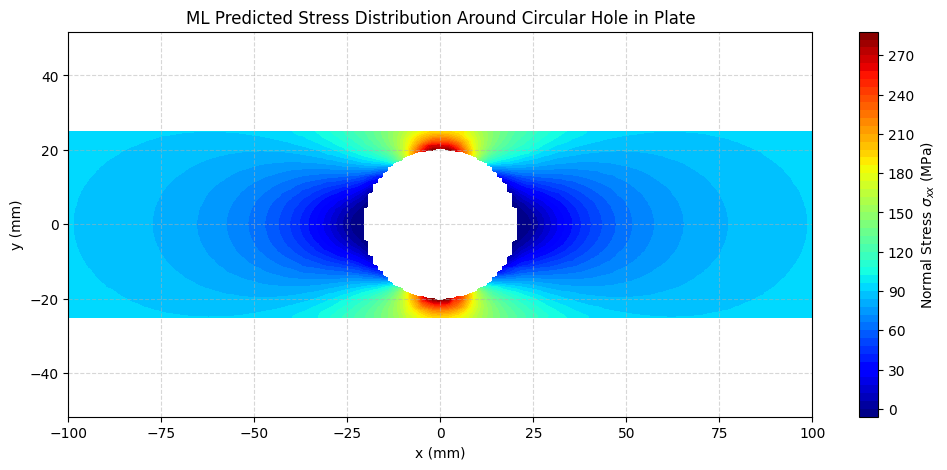

In [3]:
# Reconstruct grid for Visualization
Sigma_X_Full = np.full(X.shape, np.nan)
predicted_stresses = ml_stress_model.predict(X_features)
Sigma_X_Full[mask] = predicted_stresses

# Contour Plot
plt.figure(figsize=(12, 5))
plt.contourf(X, Y, Sigma_X_Full, levels=50, cmap='jet')
plt.colorbar(label=r'Normal Stress $\sigma_{xx}$ (MPa)')
plt.title('ML Predicted Stress Distribution Around Circular Hole in Plate')
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()